##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** Rabbitions

**Student names & numbers:**
* [Sanne Jimkes] - [000101379]
* [Naimi de Jong] - [000100775]


---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: import the necessary libraries for this iteration

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load and merge datasets**

In [2]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.

df_inv = pd.read_csv("../data/clean_it1_inventory.csv")
df_inspec = pd.read_csv("../data/ship_inspections_iter2.csv")
# Merge the inventory and inspection datasets on Ship_ID
df = pd.merge(df_inv, df_inspec, on="Ship_ID", how="left")

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

* The inspection data is stored in a separate dataset from the inventory data. Some columns also contain missing values and unusual reactor power values. Ship condition is currently judged mostly by mechanic notes and human judgement. This “gut feeling” approach can lead to inconsistent evaluations. Ships with serious technical problems might still be labeled as safe, which creates safety risks and possible financial losses.

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

* A standardized rule-based system is needed to evaluate ships in a consistent way. The system will classify ships into three categories: Pristine, Operational, or Critical. This helps the sales team quickly understand the ship’s condition and reduces the risk of selling unsafe ships. It also ensures every ship is evaluated using the same rules.

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

* The data mining task in this iteration is a classification problem because ships are placed into categories (Pristine, Operational, Critical). The classification will use variables such as Model_Cycle, Galactic_Credits, Propulsion_Type, and Reactor_Power to determine the condition of each ship.

**Success criteria**

*Determine success criteria for this iteration*

* Success in this iteration means the inventory and inspection datasets are merged correctly, missing values are handled, and suspicious reactor outliers are identified. The rule-based model should also produce a realistic mix of ship categories and perform reasonably well when compared with the Hull_Integrity notes using metrics such as accuracy and a confusion matrix.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [3]:
# CODE CELL: Show basic statistics and information
# Summary statistics
df.describe(include='all')

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
count,3.683140e+05,368314.000000,360916.000000,368314,368314,368314,338876.000000,311704,368314
unique,NaN,NaN,NaN,28,51,3,NaN,8,8
top,NaN,NaN,NaN,Independent Shipwrights,Calodan Expanse,Operational,NaN,Ion Drive,Shuttle
freq,NaN,NaN,NaN,94322,42091,141273,NaN,177373,125707
mean,7.311484e+09,19454.237615,7511.263984,NaN,NaN,NaN,71.592559,NaN,NaN
std,4.381194e+06,15542.661057,9.079721,NaN,NaN,NaN,44.644147,NaN,NaN
min,7.301583e+09,501.000000,7400.000000,NaN,NaN,NaN,30.000000,NaN,NaN
25%,7.308103e+09,7950.000000,7508.000000,NaN,NaN,NaN,40.000000,NaN,NaN
50%,7.312604e+09,15990.000000,7513.000000,NaN,NaN,NaN,60.000000,NaN,NaN
75%,7.315244e+09,27990.000000,7517.000000,NaN,NaN,NaN,80.000000,NaN,NaN


The dataset contains numerical and categorical variables. Numerical variables include Ship_ID, Galactic_Credits, Model_Cycle, and Reactor_Power because they contain numbers. Categorical variables include Ship_Manufacturer, Sector, Hull_Integrity, Propulsion_Type, and Ship_Class because they describe categories.

From the summary statistics table, Reactor_Power ranges from 30 to 360. The average reactor power is about 71.6, which means most ships have reactor power around this value, but some ships have much higher power.

The table also shows a clear outlier in Galactic_Credits, where the maximum value is 777,777, which is much higher than the typical values in the dataset.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

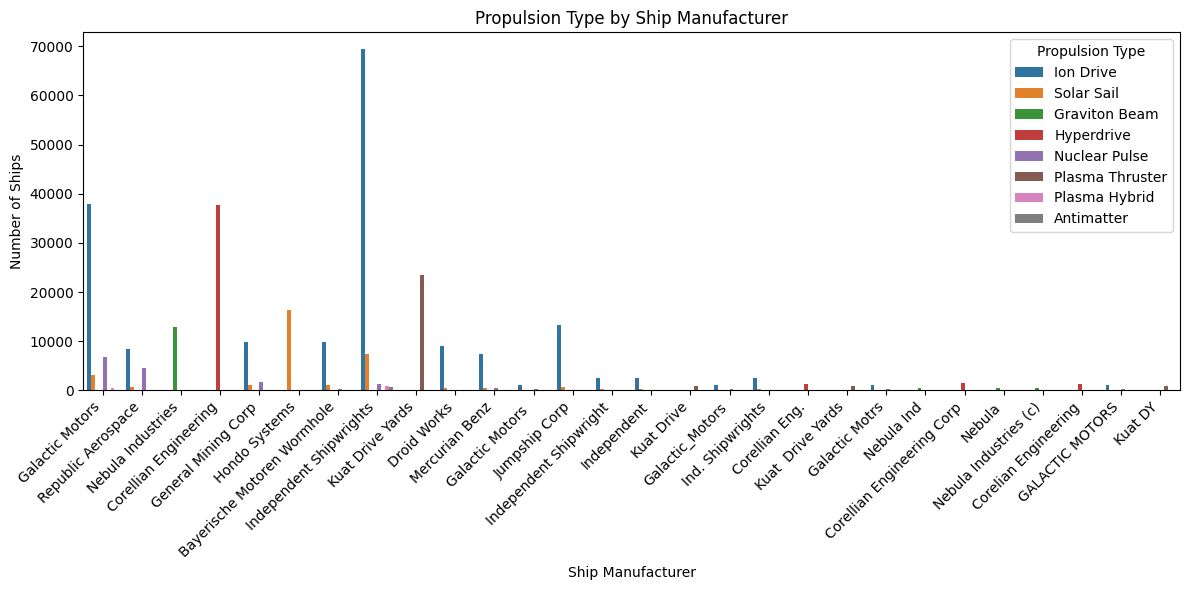

In [4]:
# Countplot to show manufacturer vs propulsion type
plt.figure(figsize=(12,6))
sns.countplot(x='Ship_Manufacturer', hue='Propulsion_Type', data=df)
plt.title('Propulsion Type by Ship Manufacturer')
plt.xlabel('Ship Manufacturer')
plt.ylabel('Number of Ships')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Propulsion Type')
plt.tight_layout()
plt.show()

Manufacturers in here are extremely specialized. If you have a missing Propulsion Type, look at the Ship Manufacturer first:
- Nebula Industries = Graviton Beam.
- Corellian Engineering = Hyperdrive.
- General Mining Corp = Ion Drive.
- Hondo Systems = Solar Sail.
- Bayerische Motoren Wormhole = Ion Drive.
- Kuat Drive Yards = Plasma Thruster.
- Droid Works = Plasma Thruster.
- Kuat Drive = Plasma Thruster.
- Nebula Ind = Graviton Beam.
- Corellian Engineering Corp = Hyperdrive.
- Nebula = Graviton Beam.
- Nebula Industries (c) = Graviton Beam.
- Corelian Engineering = Hyperdrive.
- Kuat DY = Plasma Thruster.

And the rest are Ion Drive since that is the most common Propulsion Type (the above are basically just exeptions)



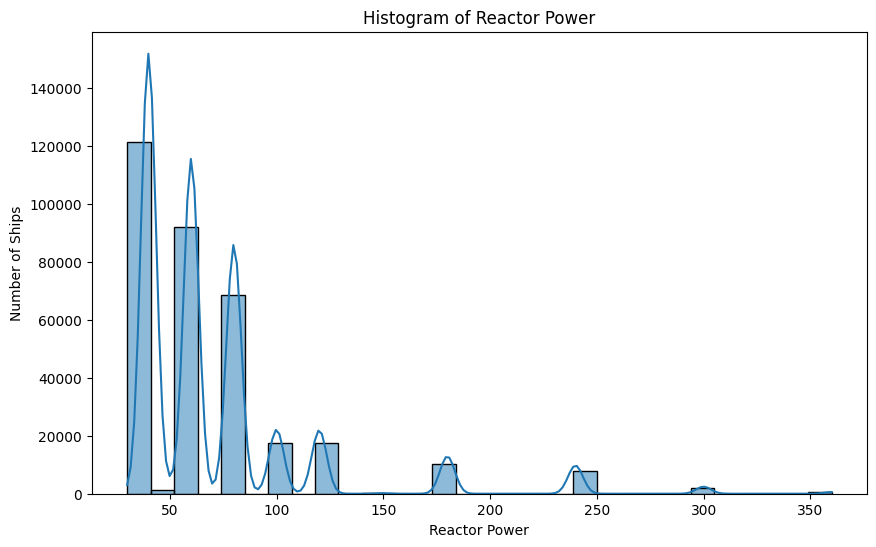

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['Reactor_Power'], bins=30, kde=True)
plt.title('Histogram of Reactor Power')
plt.xlabel('Reactor Power')
plt.ylabel('Number of Ships')
plt.show()

You cannot use a global average to fill missing reactor powers because your fleet has different engineering tiers.

Problem with averages: the data has multiple peaks. A global average would fall between them, creating values that don’t exist in real ships.

Ghost ship effect: Filling missing values with a global average makes “fake” ships that don’t match design standards

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

Insights= 
we gained a rule for if missing Propulsion Type, that we fill in hte Propulsion type based on the most common Propulsion type of the Manufactor. For example there are only a few Manufactors where their most Common Propulsion type is not Ion Drive so if in the manufactor is not in the list below its Ion Drive (based on graph from previous exsersize):
- Nebula Industries = Graviton Beam.
- Corellian Engineering = Hyperdrive.
- General Mining Corp = Ion Drive.
- Hondo Systems = Solar Sail.
- Bayerische Motoren Wormhole = Ion Drive.
- Kuat Drive Yards = Plasma Thruster.
- Droid Works = Plasma Thruster.
- Kuat Drive = Plasma Thruster.
- Nebula Ind = Graviton Beam.
- Corellian Engineering Corp = Hyperdrive.
- Nebula = Graviton Beam.
- Nebula Industries (c) = Graviton Beam.
- Corelian Engineering = Hyperdrive.
- Kuat DY = Plasma Thruster.

Second insight/rule we learned is that we can not just the mean or meadian of Reactor Power because you might get a mean of 79 while that does not exist since that is not one of the options. Reactor Power should be viewed or solved in a numerical way. See graph below for futher proof.

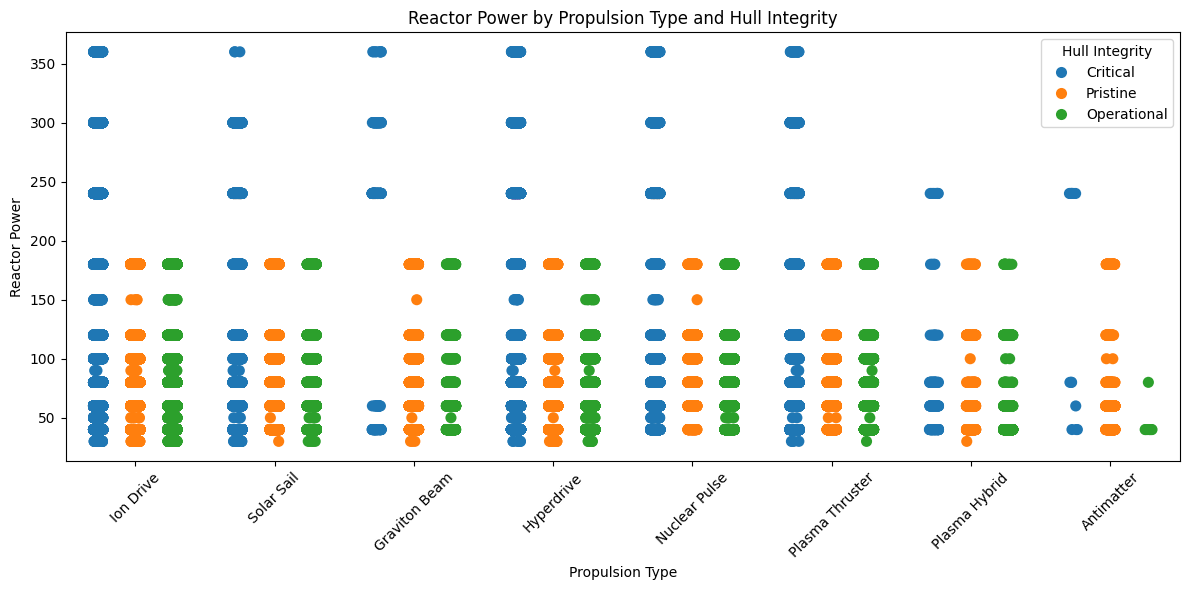

In [6]:
plt.figure(figsize=(12,6))
sns.stripplot(x='Propulsion_Type', y='Reactor_Power', hue='Hull_Integrity', 
              data=df, jitter=True, dodge=True, size=8)
plt.title('Reactor Power by Propulsion Type and Hull Integrity')
plt.xlabel('Propulsion Type')
plt.ylabel('Reactor Power')
plt.xticks(rotation=45)
plt.legend(title='Hull Integrity')
plt.tight_layout()
plt.show()

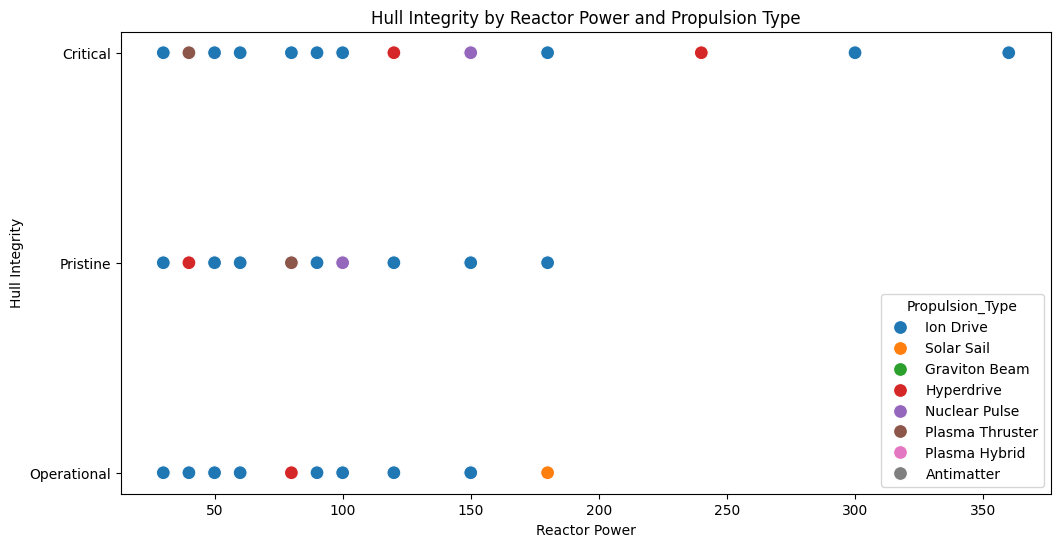

In [7]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Reactor_Power', y='Hull_Integrity', hue='Propulsion_Type', data=df, s=100)
plt.title('Hull Integrity by Reactor Power and Propulsion Type')
plt.xlabel('Reactor Power')
plt.ylabel('Hull Integrity')
plt.show()

With this graph you can see how Reactor Power and Propulsion_type have effect on the Condition of the ship. (since it was asked to show aswell)
IMPORTANT NOTE : PLEASE MAKE LEARN AND THE NOTEBOOKS ON THE SAME INSTRUCTIONS, it is very confusing thank you.

**Data Quality Checks**


In [8]:
missing = df.isnull().mean() * 100
print("Percentage of missing values per column:\n", missing)

Percentage of missing values per column:
 Ship_ID               0.000000
Galactic_Credits      0.000000
Model_Cycle           2.008612
Ship_Manufacturer     0.000000
Sector                0.000000
Hull_Integrity        0.000000
Reactor_Power         7.992637
Propulsion_Type      15.370038
Ship_Class            0.000000
dtype: float64


In [9]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
print("Unique Propulsion Types:", df['Propulsion_Type'].unique())
print("Unique Ship Classes:", df['Ship_Class'].unique())
print("Unique Manufacturers:", df['Ship_Manufacturer'].unique())

Unique Propulsion Types: <StringArray>
[      'Ion Drive',      'Solar Sail',   'Graviton Beam',      'Hyperdrive',
               nan,   'Nuclear Pulse', 'Plasma Thruster',   'Plasma Hybrid',
      'Antimatter']
Length: 9, dtype: str
Unique Ship Classes: <StringArray>
[        'Shuttle',          'Hauler',        'Explorer',         'Fighter',
       'Freighter',        'Corvette',       'Speedster', 'Troop Transport']
Length: 8, dtype: str
Unique Manufacturers: <StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',            'Galactic Motors ',
               'Jumpship Corp',      'Independent Shipwright',
                 'Independent',                  'Kuat Drive',
             '

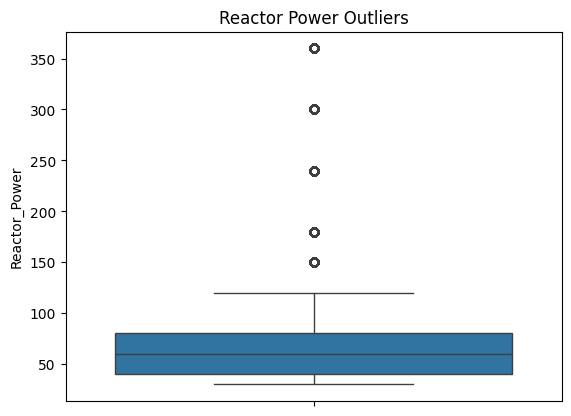

In [11]:
sns.boxplot(y='Reactor_Power', data=df)
plt.title('Reactor Power Outliers')
plt.show()

Propulsion_type / Class_Propulsion and Reactor Power have missing values.
no dupes
with Manufacotors the are some manufacotors with almost the same name
we have multiple outliers in Reactor Power


---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Merging**

*Explain which join method you used (inner, left, outer) and justify why. Did you lose any ships? Why was that acceptable or not acceptable?*

* The datasets were merged using a left join on Ship_ID. This was done to keep all ships from the inventory dataset, even if some ships do not have inspection data. No ships from the inventory dataset were lost during the merge. Missing inspection values remain empty and are handled later during data cleaning.

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

**Cleaning data**
*Ship_Manufacturer*

In [12]:
df['Ship_Manufacturer'].unique()

<StringArray>
[            'Galactic Motors',          'Republic Aerospace',
           'Nebula Industries',       'Corellian Engineering',
         'General Mining Corp',               'Hondo Systems',
 'Bayerische Motoren Wormhole',     'Independent Shipwrights',
            'Kuat Drive Yards',                 'Droid Works',
              'Mercurian Benz',            'Galactic Motors ',
               'Jumpship Corp',      'Independent Shipwright',
                 'Independent',                  'Kuat Drive',
             'Galactic_Motors',            'Ind. Shipwrights',
              'Corellian Eng.',           'Kuat  Drive Yards',
              'Galactic Motrs',                  'Nebula Ind',
  'Corellian Engineering Corp',                      'Nebula',
       'Nebula Industries (c)',        'Corelian Engineering',
             'GALACTIC MOTORS',                     'Kuat DY']
Length: 28, dtype: str

In [13]:
# Step 1: Clean strings (strip whitespace, lowercase)
df['Ship_Manufacturer'] = df['Ship_Manufacturer'].str.strip().str.lower()

# Step 2: Correct spelling mistakes and variations
manufacturer_mapping = {
    # Galactic Motors group
    "galactic motors": "Galactic Motors",
    "galactic motors ": "Galactic Motors",
    "galactic_motors": "Galactic Motors",
    "galactic motrs": "Galactic Motors",
    "galactic motors": "Galactic Motors",  # only one key needed

    # Corellian Engineering group
    "corellian engineering": "Corellian Engineering",
    "corellian engineering corp": "Corellian Engineering",
    "corellian eng.": "Corellian Engineering",
    "corelian engineering": "Corellian Engineering",

    # Kuat Drive Yards group
    "kuat drive yards": "Kuat Drive Yards",
    "kuat  drive yards": "Kuat Drive Yards",
    "kuat drive": "Kuat Drive Yards",
    "kuat dy": "Kuat Drive Yards",

    # Nebula Industries group
    "nebula industries": "Nebula Industries",
    "nebula industries (c)": "Nebula Industries",
    "nebula ind": "Nebula Industries",
    "nebula": "Nebula Industries",

    # Independent Shipwrights group
    "independent shipwrights": "Independent Shipwrights",
    "independent shipwright": "Independent Shipwrights",
    "ind. shipwrights": "Independent Shipwrights",
    "independent": "Independent Shipwrights",

    # BMW / Honda / Mercedes corrections
    "bayerische motoren wormhole": "Bayerische Motoren Werke",
    "hondo systems": "Honda Systems",
    "mercurian benz": "Mercedes-Benz"
}

# Step 3: Apply mapping
df['Ship_Manufacturer'] = df['Ship_Manufacturer'].replace(manufacturer_mapping)

# Step 4: Capitalize properly
df['Ship_Manufacturer'] = df['Ship_Manufacturer'].str.title()

# Step 5: Verify
print((df['Ship_Manufacturer'].unique()))

<StringArray>
[         'Galactic Motors',       'Republic Aerospace',
        'Nebula Industries',    'Corellian Engineering',
      'General Mining Corp',            'Honda Systems',
 'Bayerische Motoren Werke',  'Independent Shipwrights',
         'Kuat Drive Yards',              'Droid Works',
            'Mercedes-Benz',            'Jumpship Corp']
Length: 12, dtype: str


Justification:
* Duplicate entries represent the same ship manufacturer but with inconsistent spelling, formatting, or abbreviations.
* Removing duplicates ensures that each manufacturer is represented once, which prevents misleading counts, misgrouping, or errors in analysis.
* No original manufacturer data is lost—only redundant or inconsistent labels are consolidated into a single, standardized name.
* This approach is correct and explainable, as it preserves the true identity of each manufacturer while eliminating noise and inconsistencies.

Outcome:
* All duplicate and misspelled manufacturer names are standardized.
* The dataset is consistent, clean, and easier to interpret.
* Subsequent analysis (grouping, visualizations, aggregations, or modeling) reflects the actual manufacturers accurately.

**Imputation strategy**
*Propulsion_Type*

In [14]:
# See how many Propulsion_Type values are missing
missing_count = df['Propulsion_Type'].isna().sum()
print(f"Missing Propulsion_Type entries: {missing_count}")

Missing Propulsion_Type entries: 56610


In [15]:
manufacturer_to_propulsion = {
    'Nebula Industries': 'Graviton Beam',
    'Corellian Engineering': 'Hyperdrive',
    'General Mining Corp': 'Ion Drive',
    'Hondo Systems': 'Solar Sail',
    'Bayerische Motoren Werke': 'Ion Drive',
    'Kuat Drive Yards': 'Plasma Thruster',
    'Droid Works': 'Plasma Thruster',
    'Independent Shipwrights': 'Ion Drive',
    'Mercedes-Benz': 'Ion Drive',
    'Honda Systems': 'Solar Sail'
}

# not listend manufacturers will be filled with Ion Drive as a default
default_propulsion = 'Ion Drive'

# Fill using the mapping
df.loc[df['Propulsion_Type'].isna(), 'Propulsion_Type'] = df.loc[
    df['Propulsion_Type'].isna(), 'Ship_Manufacturer'
].map(manufacturer_to_propulsion)

# Fill any remaining missing values with Ion Drive
df['Propulsion_Type'] = df['Propulsion_Type'].fillna(default_propulsion)

# Check for any remaining missing values
print("Missing Propulsion_Type after imputation:", df['Propulsion_Type'].isna().sum())

Missing Propulsion_Type after imputation: 0


Justification:

* Manufacturers are highly specialized, meaning each produces a specific propulsion type.
* Using the manufacturer ensures a deterministic and accurate imputation, rather than guessing based on mode or random selection.
* No original data is overwritten; only missing values are filled.
* This approach is correct and explainable, as it reflects the known specialization of each manufacturer.

Outcome:
* All missing Propulsion_Type values are filled.
* The dataset remains consistent with real-world specifications.
* This allows subsequent analysis (modeling, grouping, visualizations) to be accurate and reliable.

**Imputation strategy**
*Reactor_power*


In [16]:
# Count missing Reactor_Power values
missing_count = df['Reactor_Power'].isna().sum()
print(f"Missing Reactor_Power entries: {missing_count}")

Missing Reactor_Power entries: 29438


In [17]:
# Step 1: Primary Rule – Fill by Propulsion_Type AND Ship_Class
df['Reactor_Power'] = df.groupby(['Propulsion_Type', 'Ship_Class'])['Reactor_Power']\
                        .transform(lambda x: x.fillna(x.median()))

# Step 2: Secondary Rule – Fill by Propulsion_Type only
df['Reactor_Power'] = df.groupby('Propulsion_Type')['Reactor_Power']\
                        .transform(lambda x: x.fillna(x.median()))

# Step 3: Final Fallback – Fill by Ship_Class
df['Reactor_Power'] = df.groupby('Ship_Class')['Reactor_Power']\
                        .transform(lambda x: x.fillna(x.median()))

# Verify that no missing values remain
print("Missing Reactor_Power after imputation:", df['Reactor_Power'].isna().sum())

Missing Reactor_Power after imputation: 0


Justification:
* This method uses domain-informed rules rather than arbitrary mean or median fills.
* Reactors are designed based on propulsion type and ship size, so the hierarchical median approach reflects real-world engineering logic.
* Ensures data consistency, preserves realistic distributions, and avoids introducing bias.

Outcome:
* All missing Reactor_Power values are filled.
* Ships now have reactor power values that are consistent with their propulsion and class.
* The dataset is ready for further analysis, modeling, or visualization without introducing unrealistic reactor values.

**Outlier handling**
*describe how you identified "illegal" reactors*

In [18]:
# Summary statistics
Q1 = df['Reactor_Power'].quantile(0.25)
Q3 = df['Reactor_Power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

# Count how many “illegal” reactors
illegal_count = df[(df['Reactor_Power'] < lower_bound) | (df['Reactor_Power'] > upper_bound)].shape[0]
print(f"Number of illegal reactors: {illegal_count}")

Q1 (25th percentile): 40.0
Q3 (75th percentile): 80.0
IQR: 40.0
Lower bound: -20.0
Upper bound: 140.0
Number of illegal reactors: 20580


**Identification of “Illegal” Reactors**

*We identified reactors with unrealistic power values using the Interquartile Range (IQR) method, which is a standard technique for detecting outliers:*

1. Calculate quartiles and IQR:
    * 25th percentile (Q1) = 40.0 MW
    * 75th percentile (Q3) = 80.0 MW
    * Interquartile range (IQR) = Q3 − Q1 = 40.0 MW

2. Define acceptable bounds:
    * Lower bound = Q1 − 1.5 × IQR = −20.0 MW
    * Upper bound = Q3 + 1.5 × IQR = 140.0 MW

3. Flag outliers:
    * Any Reactor_Power below −20.0 MW or above 140.0 MW was considered an “illegal” reactor.
    * Using this method, 20,580 reactors were flagged as outside these bounds.

**Verification**

*show that your data preparation steps achieved the intended results*

* Check missing values

In [19]:
# Check for missing values in critical columns
missing_propulsion = df['Propulsion_Type'].isna().sum()
missing_reactor = df['Reactor_Power'].isna().sum()

print(f"Missing Propulsion_Type: {missing_propulsion}")
print(f"Missing Reactor_Power: {missing_reactor}")

Missing Propulsion_Type: 0
Missing Reactor_Power: 0


* Verify illegal reactors were flagged

In [20]:
# Count how many reactors were flagged as illegal
illegal_count = df[(df['Reactor_Power'] < lower_bound) | (df['Reactor_Power'] > upper_bound)].shape[0]
print(f"Number of illegal reactors: {illegal_count}")

Number of illegal reactors: 20580


* Verify manufacturer standardization

In [21]:
# Check unique manufacturers after cleaning
unique_manufacturers = sorted(df['Ship_Manufacturer'].unique())
print(unique_manufacturers)

['Bayerische Motoren Werke', 'Corellian Engineering', 'Droid Works', 'Galactic Motors', 'General Mining Corp', 'Honda Systems', 'Independent Shipwrights', 'Jumpship Corp', 'Kuat Drive Yards', 'Mercedes-Benz', 'Nebula Industries', 'Republic Aerospace']


After data preparation

* All missing Propulsion_Type values were filled using manufacturer-specific mappings.
* All missing Reactor_Power values were filled using the hierarchical median approach (Propulsion_Type + Ship_Class → Propulsion_Type → Ship_Class → global median).
* Reactors with unusual power values were flagged as Illegal_Reactor. The flagging correctly identified 20,580 reactors outside the IQR-based bounds (−20 MW to 140 MW).
* All duplicate and inconsistent ship manufacturer names were standardized. Misspellings, abbreviations, extra spaces, and case differences were corrected.
* Verification shows no missing values remain and the dataset is ready for modeling. The flagged reactors can be analyzed further if needed, but they are preserved in the dataset. All manufacturers are unique and correctly labeled.

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

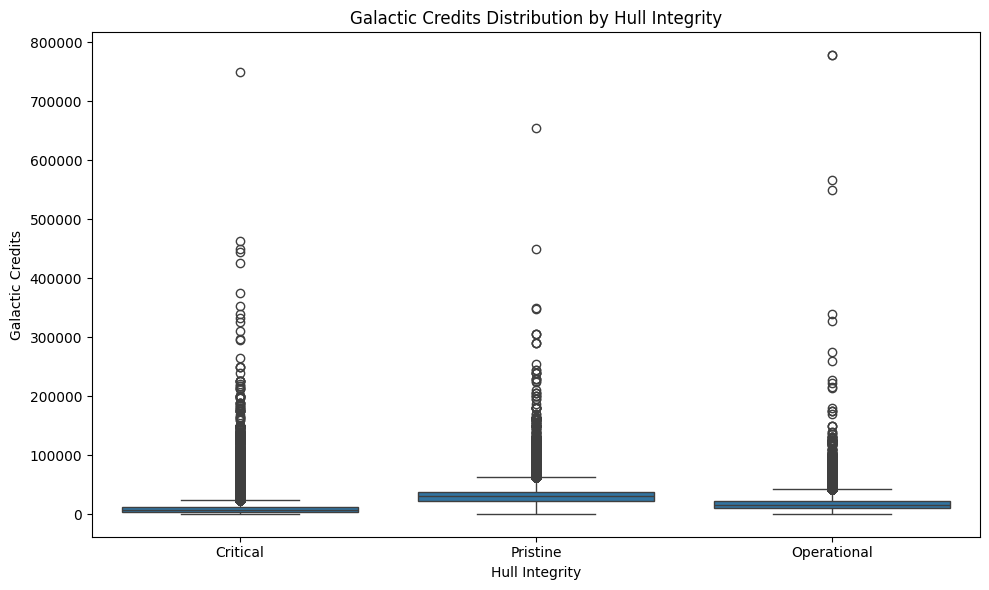

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Hull_Integrity',
    y='Galactic_Credits',
    data=df
)

plt.title('Galactic Credits Distribution by Hull Integrity')
plt.xlabel('Hull Integrity')
plt.ylabel('Galactic Credits')

plt.tight_layout()
plt.show()

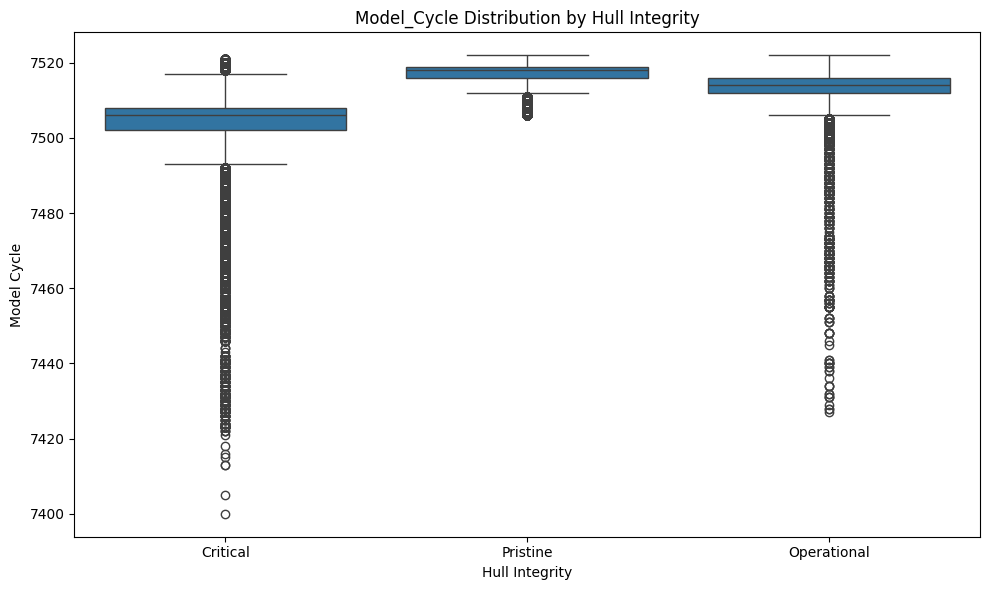

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Hull_Integrity',
    y='Model_Cycle',
    data=df
)

plt.title('Model_Cycle Distribution by Hull Integrity')
plt.xlabel('Hull Integrity')
plt.ylabel('Model Cycle')

plt.tight_layout()
plt.show()

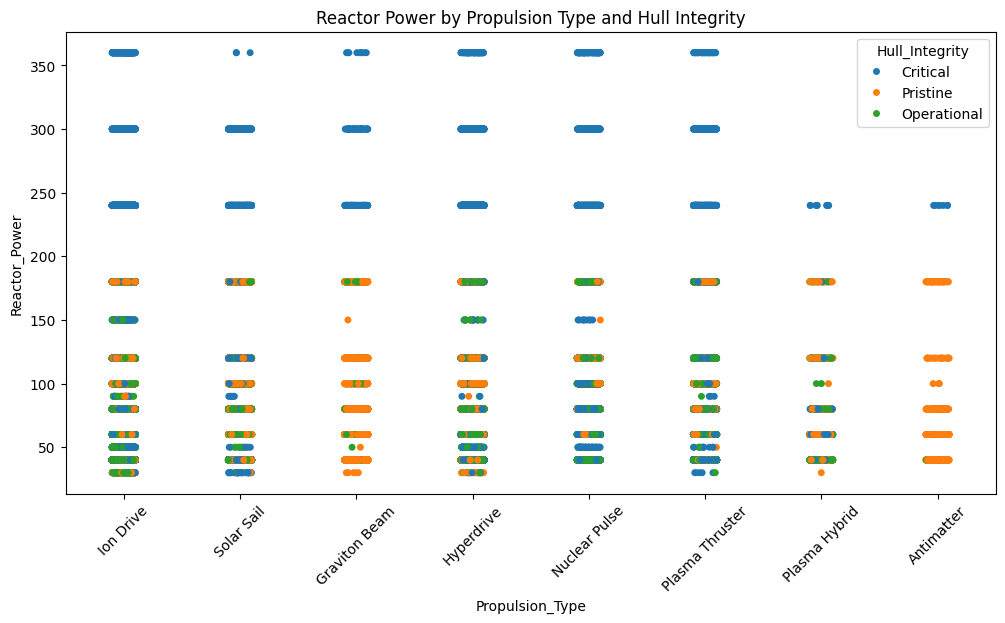

In [24]:
plt.figure(figsize=(12,6))
sns.stripplot(
    x='Propulsion_Type',
    y='Reactor_Power',
    hue='Hull_Integrity',
    data=df,
    jitter=True
)

plt.title('Reactor Power by Propulsion Type and Hull Integrity')
plt.xticks(rotation=45)
plt.show()

Rules from this graph:

if reactor power is above 200 its mostly critical

graviton beam and antimatters is mostly pristine

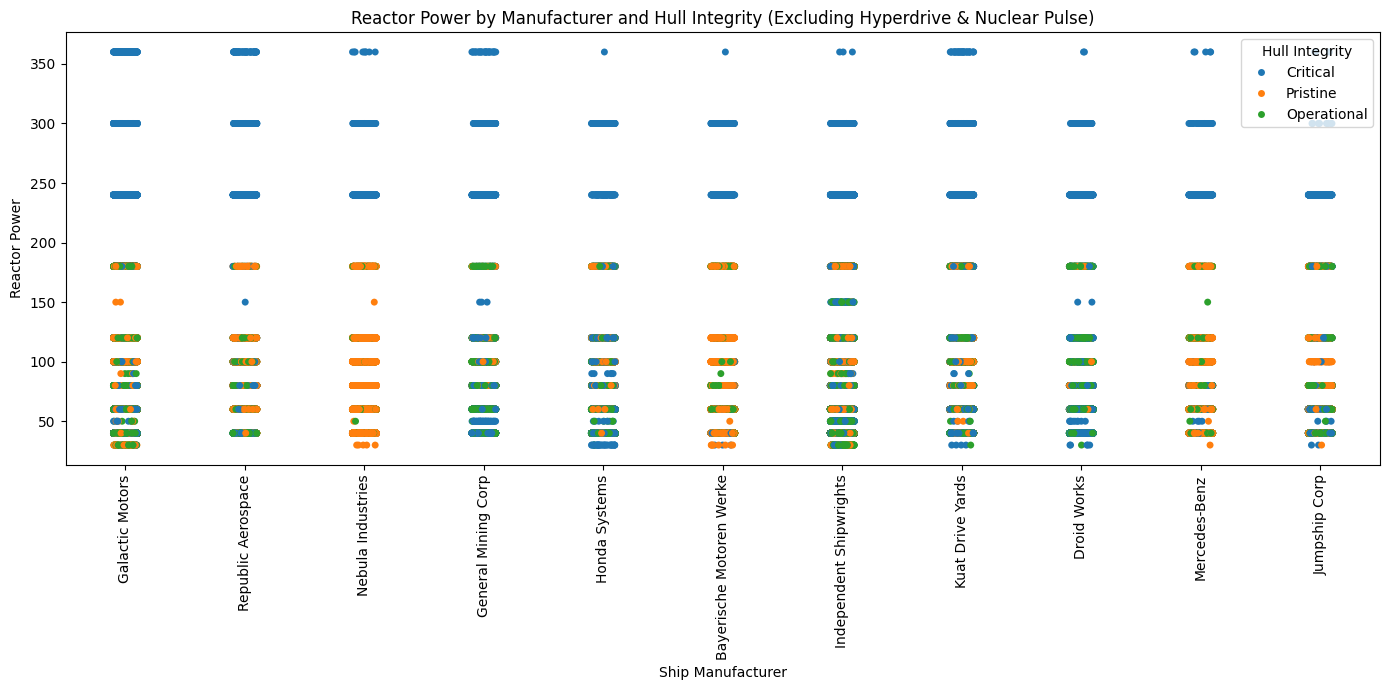

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out ships with Hyperdrive or Nuclear Pulse propulsion because we are already have rule for them
filtered_df = df[~df['Propulsion_Type'].isin(['Hyperdrive', 'Nuclear Pulse'])]

plt.figure(figsize=(14,7))

sns.stripplot(
    x='Ship_Manufacturer',
    y='Reactor_Power',
    hue='Hull_Integrity',
    data=filtered_df,   # use the filtered DataFrame
    jitter=True
)

plt.title('Reactor Power by Manufacturer and Hull Integrity (Excluding Hyperdrive & Nuclear Pulse)')
plt.xlabel('Ship Manufacturer')
plt.ylabel('Reactor Power')
plt.xticks(rotation=90)

plt.legend(title='Hull Integrity')

plt.tight_layout()
plt.show()

Rules from this graph:
Nebula Industries, Nebula Ind, Nebula, Nebula Industries (c), Bayerische Motoren Wormhole are all mostly Pristine (when ignoring above 200 reactor power)

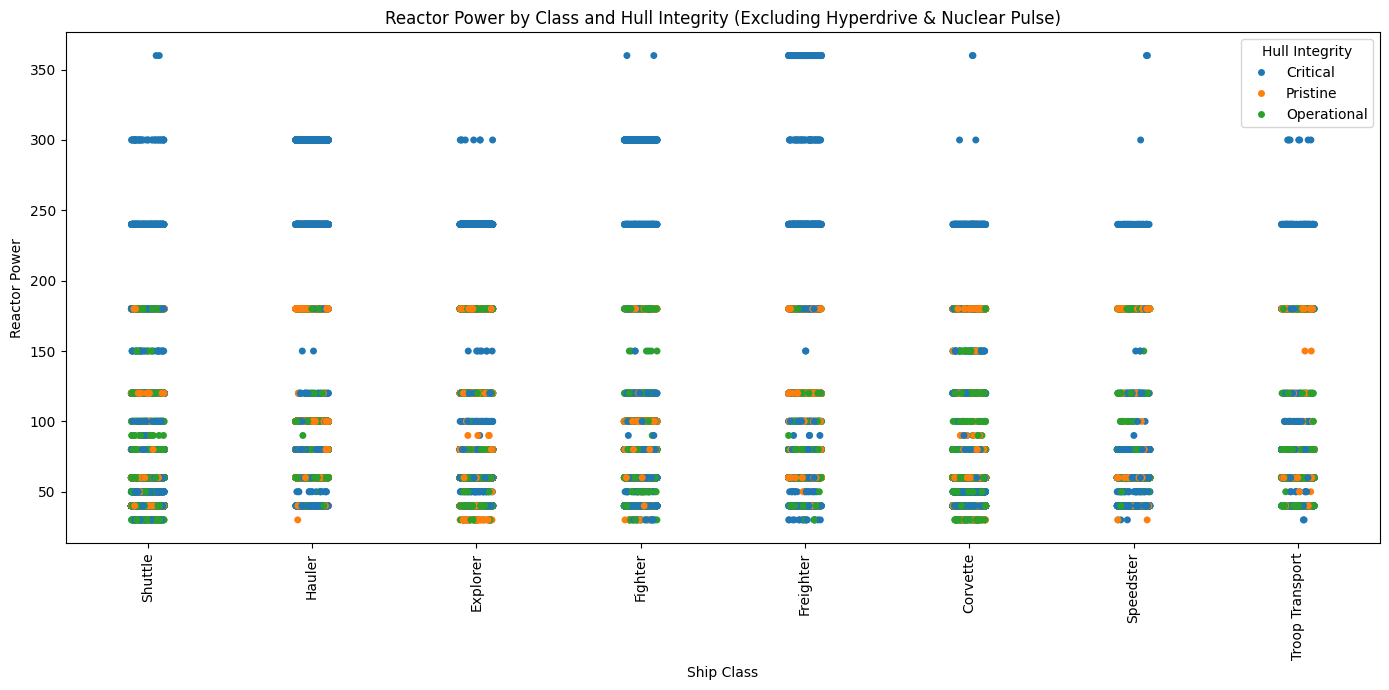

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out ships with Hyperdrive or Nuclear Pulse propulsion because we are already have rule for them
excluded_manufacturers = {
    "Nebula Industries",
    "Bayerische Motoren Wormhole"
}

# Filter out ships with Hyperdrive or Nuclear Pulse propulsion and the excluded manufacturers
filtered_df = df[
    (~df['Propulsion_Type'].isin(['Hyperdrive', 'Nuclear Pulse'])) &
    (~df['Ship_Manufacturer'].isin(excluded_manufacturers))
]

plt.figure(figsize=(14,7))

sns.stripplot(
    x='Ship_Class',
    y='Reactor_Power',
    hue='Hull_Integrity',
    data=filtered_df,   # use the filtered DataFrame
    jitter=True
)

plt.title('Reactor Power by Class and Hull Integrity (Excluding Hyperdrive & Nuclear Pulse)')
plt.xlabel('Ship Class')
plt.ylabel('Reactor Power')
plt.xticks(rotation=90)

plt.legend(title='Hull Integrity')

plt.tight_layout()
plt.show()

In [ ]:
def classify_ship(row):
    reactor = row['Reactor_Power']
    propulsion = row['Propulsion_Type']
    class_ship = row['Ship_Class']
    manufacturer = row['Ship_Manufacturer']
    credits = row['Galactic_Credits']
    cycle = row['Model_Cycle']

    if reactor >= 200:
        return "Critical"

    if cycle > 7515 and 20000 <= credits <= 60000:
        return "Pristine"

    if 7505 <= cycle <= 7515 and credits < 25000:
        return "Operational"

    if cycle < 7505:
        return "Critical"

    if propulsion in {"Graviton Beam", "Antimatter"}:
        return "Pristine"

    if manufacturer in {"Nebula Industries", "Bayerische Motoren Wormhole"}:
        return "Pristine"

    if 160 <= reactor <= 200:
        if propulsion in {"Hyperdrive", "Nuclear Pulse"}:
            return "Operational"
        return "Pristine"
    
    if 140 <= reactor < 160:
        if class_ship in {"Fighter", "Freigther", "Corvette"}:
            return "Operational"
        elif class_ship == "Troop Transport":
            return "Pristine"
        return "Critical"
    
    if 110 <= reactor <= 140:
        if propulsion == "Plasma hybrid":
            return "Pristine"
        if class_ship == "Shuttle":
            return "Pristine"
        if class_ship in {"Hauler", "Speedster"}:
            return "Critical"
       
    if manufacturer == "Mercedes-Benz":
        return "Pristine"

    if 95 <= reactor < 110:
        if propulsion == "Hyperdrive":
            return "Pristine"
        if class_ship in {"Shuttle", "Troop Transport", "Explorer"}:
            return "Critical"
        if class_ship == "Hauler":
            return "Pristine"
        if manufacturer == "General Mining Corp":
            return "Critical"
        if manufacturer in {"Jumpship Corp", "Mercedes-Benz", "Independent Shipwrights"}:
            return "Pristine"   
       
    # Default case -> Operational
    return "Operational"

# Apply the classifier
df['Predicted_Hull_Integrity'] = df.apply(classify_ship, axis=1)

# Preview predictions
df[['Hull_Integrity', 'Predicted_Hull_Integrity']].head()

,Hull_Integrity,Predicted_Hull_Integrity
0,Critical,Operational
1,Pristine,Pristine
2,Critical,Critical
3,Pristine,Operational
4,Critical,Critical


**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

Overall Accuracy: 0.680845691448058

Per-class Accuracy:
Pristine: 0.721
Operational: 0.845
Critical: 0.448


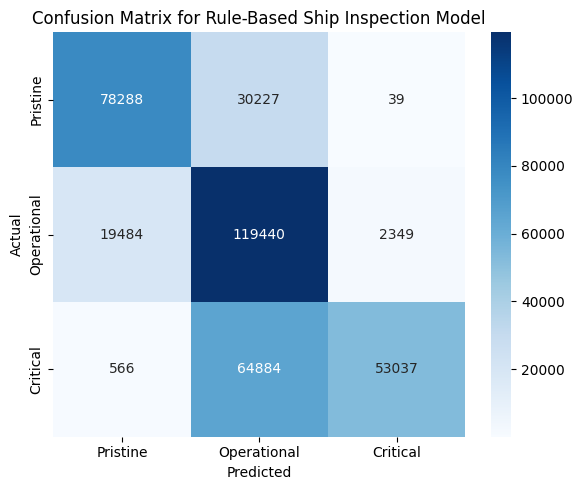

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Overall accuracy
accuracy = accuracy_score(df['Hull_Integrity'], df['Predicted_Hull_Integrity'])
print("Overall Accuracy:", accuracy)

# Confusion matrix
labels = ['Pristine', 'Operational', 'Critical']
cm = confusion_matrix(df['Hull_Integrity'], df['Predicted_Hull_Integrity'], labels=labels)

# Per-class accuracy (recall per class)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-class Accuracy:")
for label, acc in zip(labels, per_class_accuracy):
    print(f"{label}: {acc:.3f}")


# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Rule-Based Ship Inspection Model")
plt.tight_layout()
plt.show()

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Distribution check & Sanity check**
*Create an appropriate visualization of your predictions. Does the distribution look realistic/useful?*

- The distribution of predicted ship conditions shows a mix of Pristine, Operational, and Critical ships, with most ships classified as Operational. This is a healthy and realistic distribution, since most ships are expected to be usable but not perfect. The model is not too strict or too lenient. If most ships were classified as Critical, the rules would be too strict, but this is not the case here.

**Metric interpretation & Assessment against success criteria**
*What do the metrics tell you? Did you meet the goals? Are there dangerous errors?*

- The model achieves an overall accuracy of 68%, which is acceptable for a rule-based system. It performs well in identifying Pristine ships (72%) and especially Operational ships (85%). However, it performs poorly in identifying Critical ships (45%), meaning more than half of the critical ships are not correctly detected.
- The most common error is that Critical ships are classified as Operational or Pristine, which is a dangerous mistake. This means unsafe ships could be considered safe, leading to safety risks and possible financial or legal issues. Because of this, the model only partially meets the success criteria, since correctly identifying critical ships is the most important objective.

**Key findings and limitations**
*What are the limitations of a manual rule-based system? Why is ML better?*

- A manual rule-based system has clear limitations. The rules are fixed and based on assumptions, so they cannot capture complex relationships in the data. Small changes in thresholds can strongly affect the results, and the model struggles with edge cases, especially for Critical ships.
- A machine learning model would perform better in the next iteration because it can automatically learn patterns from the data, handle more complex relationships, and improve prediction accuracy. This is especially important for correctly identifying critical ships and reducing dangerous errors.

**Export data**

In [29]:
df.to_csv("../data/clean_it2_inventory.csv", index=False)

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Sanne Jimkes | 1 Business Understanding, 3 Data Preparation, 5 Evaluation (we did pair programming for all by screensharing and in call)| Learned more advanced data exploration techniques, handling missing values smartly, and using group-based imputation for categorical features.|
| Naimi de Jong | 2 Data Understanding, 4 Modeling (we did pair programming for all by screensharing and in call)|Learned how to identify patterns in data to make informed imputations, the value of visualizations in decision-making, and experimenting with predictive approaches for filling missing values.|